# DSC 680 -  Applied Data Science #
## Project 1: Predicting Stroke Risk Using Machine Learning ##
### Manoj K Kola ###

Today, I will attempt to **predict whether or not an individual will suffer a stroke.**

First, I will perform extensive data visualization. This will help me to see if there are any features that look to be indicative of a stroke, or indeed of not having a stroke.

Next, I will build multiple models and select the best-performing one. I will use the F1 score as my primary metric, as our dataset is imbalanced (though I will also resolve this with SMOTE).

#### Model Interpretation

**I will also delve into Model Interpretation**
This is incredibly important in industry. Often, we need to explain very technical algorithms to a non-technical audience, so any tool that can help this process should be mastered.


### Library Imports & Setup

#### 1. Core Data & Visualization Libraries

| Library | Purpose |
|---|---|
| `pandas` | Loading, cleaning, and manipulating tabular data (DataFrames) |
| `numpy` | Numerical operations and array manipulation |
| `matplotlib` | Base plotting library for charts and graphs |
| `seaborn` | High-level visualization built on matplotlib (cleaner statistical plots) |

#### 2. Train/Test Split

Splits the dataset into **training** and **testing** subsets. The model learns from the training set and is evaluated on the unseen test set to measure real-world performance.

#### 3. Preprocessing — Scaling & Encoding

- **`StandardScaler`** — Standardizes numerical features to have mean = 0 and standard deviation = 1. Prevents features with large ranges (e.g., income vs. age) from dominating the model.
- **`OneHotEncoder`** — Converts categorical variables (e.g., `["cat", "dog"]`) into binary columns so ML models can process them numerically.

#### 4. Pipeline & Column Transformer

- **`ColumnTransformer`** — Applies different preprocessing steps to different column types (e.g., scale numerics, encode categoricals) in one step.
- **`Pipeline`** — Chains preprocessing and model training into a single, reproducible workflow. Prevents data leakage by ensuring transformations only fit on training data.

#### 5. Evaluation Metrics

| Metric | What It Measures |
|---|---|
| `accuracy_score` | % of correct predictions overall |
| `precision_score` | Of predicted positives, how many were actually positive |
| `recall_score` | Of all actual positives, how many did the model catch |
| `f1_score` | Harmonic mean of precision & recall — useful for imbalanced data |
| `roc_auc_score` | Model's ability to distinguish between classes across thresholds |
| `confusion_matrix` | Breakdown of TP, TN, FP, FN predictions |
| `classification_report` | Summary of all above metrics per class |

#### 6. Classification Models

| Model | Strengths |
|---|---|
| `LogisticRegression` | Fast, interpretable baseline for binary classification |
| `DecisionTreeClassifier` | Intuitive, handles non-linear boundaries, prone to overfitting |
| `RandomForestClassifier` | Ensemble of trees — reduces overfitting, robust and accurate |
| `XGBClassifier` | Gradient boosting — often top performer on structured/tabular data |

#### 7. Class Imbalance Handling

**SMOTE (Synthetic Minority Oversampling Technique)** — If one class has far fewer examples (e.g., fraud = 2%, not-fraud = 98%), the model will bias toward the majority class. SMOTE synthetically generates new minority-class samples to balance the dataset, improving recall on the rare class.

In [25]:
# Import libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import function to split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import preprocessing tools for scaling and encoding data
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Import tools to apply different preprocessing steps to columns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Import model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Import machine learning classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Import the XGBoost classifier
from xgboost import XGBClassifier

# Import SMOTE to balance the dataset by oversampling the minority class
from imblearn.over_sampling import SMOTE

### Load & Preview Data

Reads the stroke dataset from a CSV file into a pandas DataFrame. `.head()` returns the first 5 rows to verify that the data loaded correctly and to inspect the column structure.

In [29]:
# Load the stroke dataset into a DataFrame
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Display the first 5 rows to preview the data
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Dataset Overview

#### Structure & Data Types
Prints a summary of the DataFrame — column names, non-null counts, and data types. Helps identify missing values and confirm columns are loaded correctly.

#### Target Class Distribution
Counts occurrences of each class in the `stroke` column (0 = no stroke, 1 = stroke). Critical first check for class imbalance before modeling.

In [57]:
# Display basic information about the dataset
print(df.info())

# Display the number of stroke and non-stroke cases
print("\n", df["stroke"].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   object 
 1   age                5109 non-null   float64
 2   hypertension       5109 non-null   int64  
 3   heart_disease      5109 non-null   int64  
 4   ever_married       5109 non-null   object 
 5   work_type          5109 non-null   object 
 6   Residence_type     5109 non-null   object 
 7   avg_glucose_level  5109 non-null   float64
 8   bmi                5109 non-null   float64
 9   smoking_status     5109 non-null   object 
 10  stroke             5109 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 479.0+ KB
None

 stroke
0    4860
1     249
Name: count, dtype: int64


### Data Cleaning
#### 1. Drop Irrelevant Column

Removed the `id` — a unique identifier with no predictive value. Keeping it would add noise and could cause the model to overfit.

#### 2. Clean & Impute BMI

`bmi` is cast to numeric (forcing non-numeric values to `NaN`), and missing values are filled with the **median**. The median is preferred over the mean here because it is robust to outliers, which are common in BMI distributions.

#### 3. Remove Rare Gender Category

Rows where `gender == "Other"` are dropped. With only one record, this category provides no statistical signal, potentially destabilizing encoding during preprocessing.

In [30]:
# Remove the 'id' column because it does not help predict stroke
df = df.drop(columns=["id"])

# Convert BMI to numeric values and replace missing values with the median BMI
df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")
bmi_median = df["bmi"].median()
df["bmi"] = df["bmi"].fillna(bmi_median)

# Remove the "Other" gender category because it contains only one record
df = df[df["gender"] != "Other"]

### Exploratory Data Analysis (EDA)

#### Stroke Class Distribution Plot

Sets up a **count plot** to visualize how many patients had a stroke vs. did not — a critical first step to detect class imbalance before modeling.

**Why this matters:** If class `0` vastly outnumbers class `1`, the dataset is imbalanced — this justifies the use of **SMOTE** later in the pipeline.

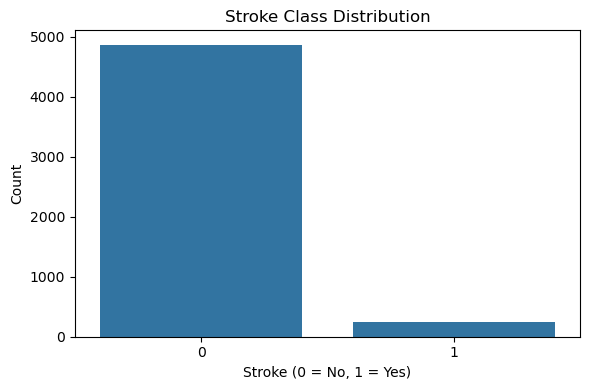

In [31]:
# Set the figure size for better readability
plt.figure(figsize=(6, 4))

# Create a count plot to show the distribution of stroke classes (0 = No stroke, 1 = Stroke)
sns.countplot(x="stroke", data=df)

# Add a title to the plot
plt.title("Stroke Class Distribution")

# Label the x-axis to explain stroke categories
plt.xlabel("Stroke (0 = No, 1 = Yes)")

# Label the y-axis to show the number of records
plt.ylabel("Count")

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display the plot
plt.show()

#### Age Distribution Plot

Sets up an 8×5 figure and plots a histogram of the `age` column with 30 bins. The `kde=True` overlay adds a smooth density curve to highlight the overall distribution shape. Axes are labeled, and `tight_layout()` prevents any overlap before rendering.

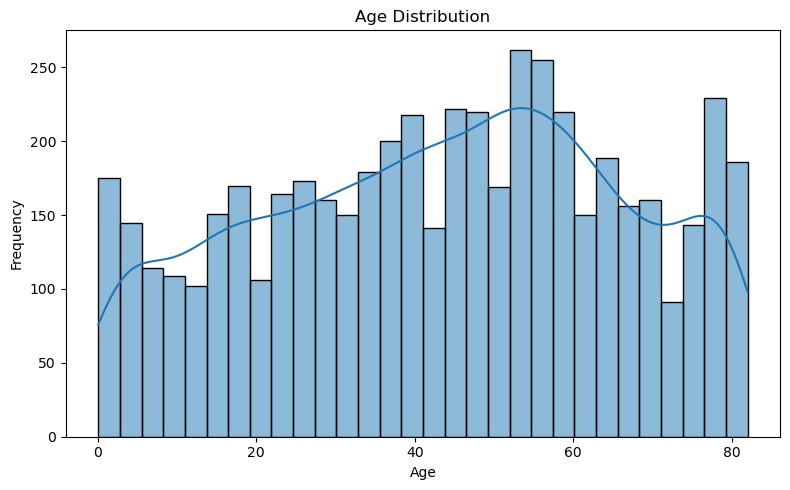

In [32]:
# Create a figure with a specific size (width=8, height=5)
plt.figure(figsize=(8, 5))

# Plot the distribution of the 'age' column using a histogram
# bins=30 divides the data into 30 intervals
# kde=True adds a smooth density curve to show the distribution trend
sns.histplot(df["age"], bins=30, kde=True)

# Set the title of the plot
plt.title("Age Distribution")

# Label the x-axis as Age
plt.xlabel("Age")

# Label the y-axis as Frequency (count of records in each age range)
plt.ylabel("Frequency")

# Adjust layout to prevent overlap of labels and title
plt.tight_layout()

# Display the final plot
plt.show()

#### Boxplot — Average Glucose Level by Stroke Outcome

Creates a boxplot comparing glucose distributions between stroke (1) and non-stroke (0) patients.

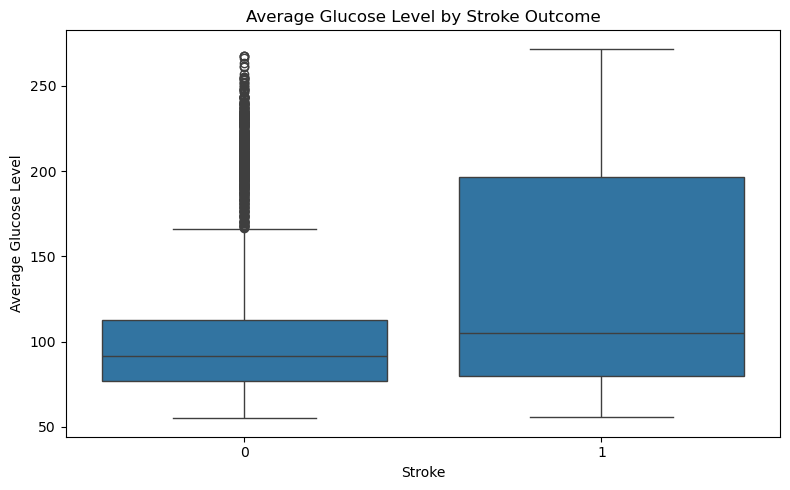

In [33]:
# Set the figure size for the plot (width = 8, height = 5)
plt.figure(figsize=(8, 5))

# Create a boxplot to compare glucose levels between stroke and non-stroke patients
sns.boxplot(x="stroke", y="avg_glucose_level", data=df)

# Add a title to the plot
plt.title("Average Glucose Level by Stroke Outcome")

# Label the x-axis (stroke outcome: 0 = No stroke, 1 = Stroke)
plt.xlabel("Stroke")

# Label the y-axis (average glucose level values)
plt.ylabel("Average Glucose Level")

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display the final plot
plt.show()

#### BMI Distribution by Stroke Outcome

Creates a boxplot comparing BMI spread across stroke (1) and no-stroke (0) groups.

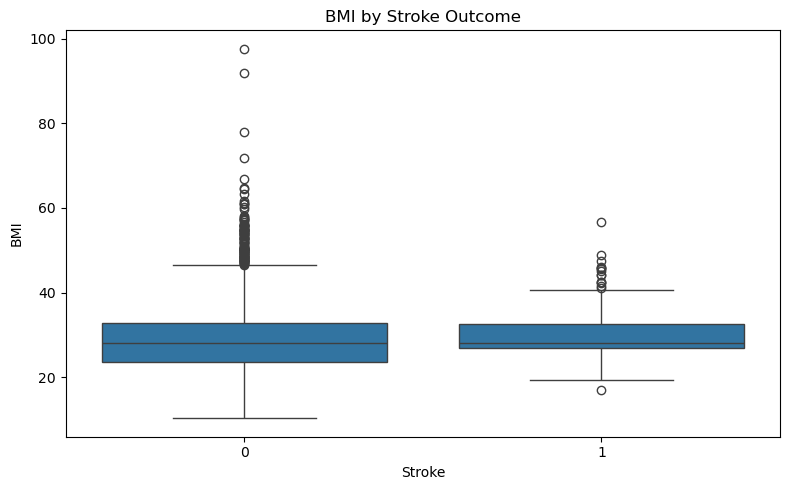

In [35]:
# Create a figure with a specified size
plt.figure(figsize=(8, 5))

# Create a boxplot to compare BMI values based on stroke outcome (0 = No stroke, 1 = Stroke)
sns.boxplot(x="stroke", y="bmi", data=df)

# Add a title to the plot
plt.title("BMI by Stroke Outcome")

# Label the x-axis
plt.xlabel("Stroke")

# Label the y-axis
plt.ylabel("BMI")

# Adjust layout to prevent overlap of labels and elements
plt.tight_layout()

# Display the plot
plt.show()

#### Correlation Heatmap — Numeric Features

Selects key numeric columns and plots a heatmap to visualize pairwise correlations between features and the target variable (`stroke`).

**Why it matters:** Helps identify which features (e.g., `age`, `bmi`, `avg_glucose_level`) are most correlated with stroke risk and flags multicollinearity between predictors before modeling.

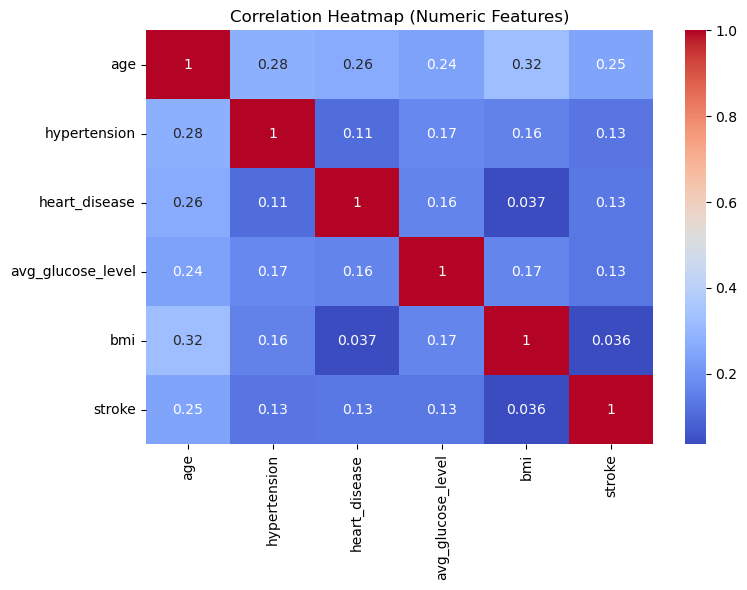

In [40]:
# Select important numeric features for correlation analysis
numeric_cols = ["age", "hypertension", "heart_disease",
                "avg_glucose_level", "bmi", "stroke"]

# Set the figure size for better readability
plt.figure(figsize=(8, 6))

# Create a correlation heatmap to show relationships between numeric features
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")

# Add a title to the plot
plt.title("Correlation Heatmap (Numeric Features)")

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plot
plt.show()

### Feature Engineering & Preprocessing

#### 1. Feature / Target Split

- **`X`** — All input features (every column except `stroke`)
- **`y`** — Target variable (`stroke`: what the model predicts)

#### 2. Feature Definitions

| Type | Features |
|---|---|
| Numerical | `age`, `hypertension`, `heart_disease`, `avg_glucose_level`, `bmi` |
| Categorical | `gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status` |

#### 3. Transformers

- **`StandardScaler`** — Rescales all numerical features to mean = 0, std = 1. Prevents high-range features like `avg_glucose_level` from outweighing smaller ones like `bmi`.
- **`OneHotEncoder`** — Converts categorical strings into binary columns. `handle_unknown="ignore"` ensures unseen categories at inference time don't break the pipeline.

#### 4. ColumnTransformer

Bundles both transformers into a single `preprocessor` object that routes each column to the correct transformation — numerical columns to `StandardScaler`, categorical to `OneHotEncoder` — keeping the pipeline clean and leak-free.

In [41]:
# Separate features (inputs) and target variable (output)
X = df.drop(columns=["stroke"])
y = df["stroke"]

# List of numerical features in the dataset
numeric_features = ["age", "hypertension", "heart_disease",
                    "avg_glucose_level", "bmi"]

# List of categorical features in the dataset
categorical_features = ["gender", "ever_married", "work_type",
                        "Residence_type", "smoking_status"]

# Apply standard scaling to numerical features
# This ensures all numeric values are on the same scale
numeric_transformer = StandardScaler()

# Apply one-hot encoding to categorical features
# This converts categories into numeric binary columns
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

# Combine preprocessing steps for both numeric and categorical data
# ColumnTransformer applies the correct transformation to each column type
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### Train/Test Split

Divides data into **70% training** and **30% testing** subsets.

**Why stratify?** Stroke datasets are heavily imbalanced. Without stratification, one split could end up with a disproportionate number of stroke cases, skewing both training and evaluation.

In [42]:
# Split the dataset into training and testing sets
# X = input features, y = target variable (stroke)
# test_size=0.3 means 30% of the data is used for testing and 70% for training
# random_state=42 ensures the split is reproducible (same result every time)
# stratify=y ensures the class distribution (stroke vs no stroke) is maintained in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

### Preprocessing & Class Balancing

#### 1. Fit & Transform Training Data

The preprocessor (scaling, encoding) is **fit on training data only**, then applied — ensuring no information from the test set leaks into the pipeline.

#### 2. Apply SMOTE

`random_state=42` ensures reproducibility. SMOTE is applied **after** preprocessing so synthetic samples are generated in the scaled/encoded feature space, not raw data.

#### 3. Class Distribution Check

Prints class counts before and after SMOTE to confirm the minority class has been balanced. Always verify this — a successful resample should show equal (or near-equal) class counts.

**Why this order matters:** Preprocess → then resample. Applying SMOTE on raw data before encoding can produce invalid synthetic values for categorical features.

In [43]:
# Apply preprocessing steps (encoding, scaling, etc.) to the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Initialize SMOTE to handle class imbalance in the training dataset
smote = SMOTE(random_state=42)

# Apply SMOTE to create a balanced training dataset by oversampling the minority class
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

# Display original class distribution before SMOTE
print("Original training class distribution:")
print(y_train.value_counts())

# Display new class distribution after applying SMOTE
print("\nResampled training class distribution:")
print(y_train_resampled.value_counts())

Original training class distribution:
stroke
0    3402
1     174
Name: count, dtype: int64

Resampled training class distribution:
stroke
0    3402
1    3402
Name: count, dtype: int64


### Model Training Function `evaluate_model`

Trains, predicts, and scores a single classifier. Returns a results dictionary for cross-model comparison.

#### Parameters

| Parameter | Description |
|---|---|
| `name` | Display name of the model |
| `model` | Unfitted classifier instance |
| `X_train_res` | SMOTE-resampled training features |
| `y_train_res` | SMOTE-resampled training labels |
| `X_test` | Raw test features |
| `y_test` | True test labels |
| `preprocessor` | Already-fitted `ColumnTransformer` |

#### Steps

**1. Preprocess test data** — Applies the already-fitted preprocessor to `X_test`. Fitted on training data only to prevent data leakage.

**2. Train the model** — Fits the classifier on the SMOTE-balanced training data.

**3. Predict** — Generates class predictions (`y_pred`) and probability scores (`y_proba`) on the processed test set. Probabilities are required for ROC-AUC.

**4. Score** — Computes five metrics against the true labels:

| Metric | Variable | Purpose |
|---|---|---|
| Accuracy | `acc` | Overall correct prediction rate |
| Precision | `prec` | Quality of positive predictions |
| Recall | `rec` | Coverage of actual positives |
| F1 Score | `f1` | Balance of precision and recall |
| ROC-AUC | `roc` | Ranking ability across thresholds |

**5. Output** — Prints a formatted summary including all metrics, a confusion matrix, and a full classification report.

**6. Return** — Yields a flat dictionary so results from all models can be collected and compared in a DataFrame.

In [47]:
def evaluate_model(name, model, X_train_res, y_train_res, X_test, y_test, preprocessor):
    # Transform the test data using the already fitted preprocessing pipeline
    X_test_processed = preprocessor.transform(X_test)

    # Train the model using the resampled training data
    model.fit(X_train_res, y_train_res)

    # Make predictions on the test dataset
    y_pred = model.predict(X_test_processed)

    # Get probability scores for ROC-AUC calculation
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)          # Accuracy
    prec = precision_score(y_test, y_pred)        # Precision
    rec = recall_score(y_test, y_pred)            # Recall
    f1 = f1_score(y_test, y_pred)                 # F1-score
    roc = roc_auc_score(y_test, y_proba)          # ROC-AUC score

    # Confusion matrix to show correct vs incorrect predictions
    cm = confusion_matrix(y_test, y_pred)

    # Display model performance results
    print("*" * 60)
    print(f"  Model: {name}")  # Display model name
    print("*" * 60)
    # print(f"\n=== {name} ===")
    print("Accuracy:", round(acc, 3))
    print("Precision:", round(prec, 3))
    print("Recall:", round(rec, 3))
    print("F1 Score:", round(f1, 3))
    print("ROC-AUC:", round(roc, 3))
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Return results as a dictionary for comparison across models
    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": roc
    }

### Model Training & Evaluation

A shared `results` list collects evaluation outputs from all four models, enabling side-by-side comparison at the end.

#### 1. Logistic Regression

`class_weight="balanced"` automatically adjusts sample weights inversely proportional to class frequency — compensating for imbalance without manual tuning. `max_iter=1000` ensures convergence on larger datasets.

#### 2. Decision Tree

`class_weight="balanced"` applies the same imbalance correction as above. `random_state=42` ensures reproducibility across runs.

#### 3. Random Forest

`n_estimators=200` builds 200 decision trees and aggregates their predictions to reduce variance and overfitting. `class_weight="balanced_subsample"` recalculates class weights on each bootstrap sample rather than globally — better suited for ensemble methods.

#### 4. XGBoost

Gradient boosting model with tuned hyperparameters to balance performance and generalization:

| Parameter | Value | Purpose |
|---|---|---|
| `n_estimators` | 300 | Number of boosting rounds |
| `max_depth` | 4 | Shallow trees to limit overfitting |
| `learning_rate` | 0.05 | Slow learning for better generalization |
| `subsample` | 0.8 | 80% of rows sampled per tree |
| `colsample_bytree` | 0.8 | 80% of features sampled per tree |
| `objective` | binary:logistic | Binary classification output |
| `eval_metric` | logloss | Probabilistic loss for evaluation |

In [48]:
# List to store evaluation results of all models
results = []

# ---------------- Logistic Regression Model ----------------
# Create a Logistic Regression model with balanced class weights
# to handle class imbalance in the dataset
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

# Train and evaluate the model, then store the results
results.append(
    evaluate_model("Logistic Regression", log_reg,
                   X_train_resampled, y_train_resampled,
                   X_test, y_test, preprocessor)
)

# ---------------- Decision Tree Model ----------------
# Create a Decision Tree model with balanced class weights
# for better handling of imbalanced classes
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")

# Train and evaluate the model, then store the results
results.append(
    evaluate_model("Decision Tree", dt,
                   X_train_resampled, y_train_resampled,
                   X_test, y_test, preprocessor)
)

# ---------------- Random Forest Model ----------------
# Create a Random Forest model with 200 trees
# using balanced subsampling to handle class imbalance
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced_subsample"
)

# Train and evaluate the model, then store the results
results.append(
    evaluate_model("Random Forest", rf,
                   X_train_resampled, y_train_resampled,
                   X_test, y_test, preprocessor)
)

# ---------------- XGBoost Model ----------------
# Create XGBoost classifier with tuned hyperparameters
# to improve performance and reduce overfitting
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

# Train and evaluate the model, then store the results
results.append(
    evaluate_model("XGBoost", xgb,
                   X_train_resampled, y_train_resampled,
                   X_test, y_test, preprocessor)
)

************************************************************
  Model: Logistic Regression
************************************************************
Accuracy: 0.747
Precision: 0.137
Recall: 0.787
F1 Score: 0.233
ROC-AUC: 0.838
Confusion Matrix:
 [[1086  372]
 [  16   59]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.74      0.85      1458
           1       0.14      0.79      0.23        75

    accuracy                           0.75      1533
   macro avg       0.56      0.77      0.54      1533
weighted avg       0.94      0.75      0.82      1533

************************************************************
  Model: Decision Tree
************************************************************
Accuracy: 0.882
Precision: 0.104
Recall: 0.187
F1 Score: 0.134
ROC-AUC: 0.552
Confusion Matrix:
 [[1338  120]
 [  61   14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96 

### Model Comparison & Visualization

Converts the results list into a DataFrame for structured comparison, then prints a summary table of all model metrics side-by-side.

Plots a bar chart using `seaborn` to visually rank models by **ROC-AUC score** — the higher the bar, the better the model's ability to distinguish between classes. Layout adjustments ensure labels and titles render cleanly without overlap.


Model Comparison:
                  Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  Logistic Regression  0.746902   0.136891  0.786667  0.233202  0.838226
1        Decision Tree  0.881931   0.104478  0.186667  0.133971  0.552181
2        Random Forest  0.932811   0.208333  0.133333  0.162602  0.769451
3              XGBoost  0.914547   0.202128  0.253333  0.224852  0.780540


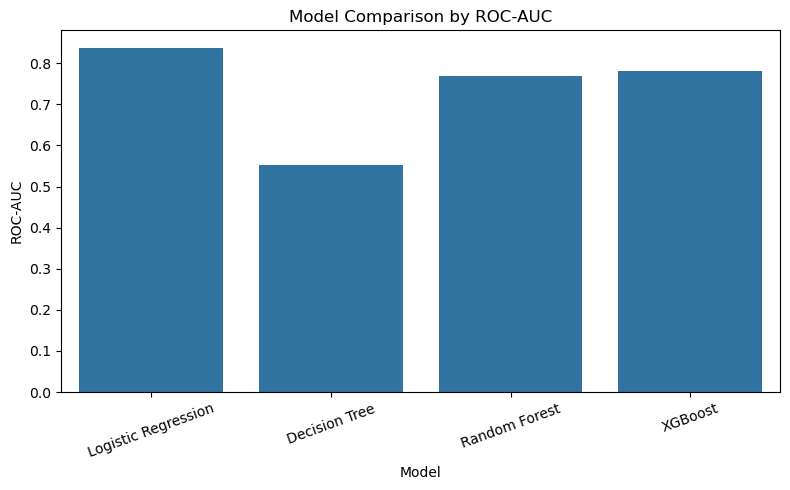

In [49]:
# Convert the results list into a DataFrame for easy comparison of models
results_df = pd.DataFrame(results)

# Display the model performance summary table
print("\nModel Comparison:\n", results_df)

# Create a new figure for visualization with a specified size
plt.figure(figsize=(8, 5))

# Plot a bar chart to compare ROC-AUC scores of different models
sns.barplot(x="Model", y="ROC_AUC", data=results_df)

# Add a title to the plot
plt.title("Model Comparison by ROC-AUC")

# Label the y-axis
plt.ylabel("ROC-AUC")

# Rotate x-axis labels slightly for better readability
plt.xticks(rotation=20)

# Adjust layout to prevent overlap of elements
plt.tight_layout()

# Display the plot
plt.show()

### Feature Importance Analysis — Random Forest

Extracts and ranks the most influential features from the trained Random Forest model.

| Step | What & Why |
|---|---|
| `get_feature_names_out()` | Retrieves the expanded column names created by `OneHotEncoder` — each category becomes its own named binary column |
| `numeric_features + list(cat_feature_names)` | Combines numeric and encoded categorical names into one aligned list matching the model's input order |
| `rf.feature_importances_` | Pulls the built-in Random Forest importance scores — measures how much each feature reduces impurity across all trees |
| `pd.DataFrame(...).sort_values()` | Maps each feature name to its score and ranks them descending for readability |
| `feat_imp.head(15)` | Surfaces the top 15 drivers — useful for feature selection, model explainability, and spotting noise variables |

In [54]:
# Get feature names created after preprocessing (one-hot encoding for categorical variables)
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)

# Combine numeric and categorical feature names into a single list
all_feature_names = numeric_features + list(cat_feature_names)

# Extract feature importance values from the trained Random Forest model
importances = rf.feature_importances_

# Create a DataFrame to map each feature to its importance score
feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Display the top 15 most important features
print("\nTop 15 Features by Importance (Random Forest):\n", feat_imp.head(15))




Top 15 Features by Importance (Random Forest):
                            feature  importance
0                              age    0.321200
4                              bmi    0.112616
3                avg_glucose_level    0.108015
7                  ever_married_No    0.048230
8                 ever_married_Yes    0.047962
18     smoking_status_never smoked    0.039839
11               work_type_Private    0.033797
12         work_type_Self-employed    0.030448
17  smoking_status_formerly smoked    0.030146
16          smoking_status_Unknown    0.027163
6                      gender_Male    0.026748
14            Residence_type_Rural    0.026479
15            Residence_type_Urban    0.025352
5                    gender_Female    0.025207
9               work_type_Govt_job    0.023832


### Top 15 Feature Importances — Visualization

Creates a horizontal bar chart ranking the 15 most influential features from the Random Forest model.

| Line | Purpose |
|---|---|
| `plt.figure(figsize=(10, 6))` | Sets canvas size — wide enough to read feature names clearly |
| `sns.barplot(x="importance", y="feature", ...)` | Plots importance scores on the x-axis, feature names on the y-axis |
| `feat_imp.head(15)` | Slices only the top 15 rows, assuming `feat_imp` is sorted descending |
| `plt.title / xlabel / ylabel` | Labels the chart for readability and context |
| `plt.tight_layout()` | Auto-adjusts spacing to prevent axis labels or titles from clipping |
| `plt.show()` | Renders and displays the final plot |

**Why it matters** — Feature importance reveals which variables the model relies on most when making predictions. This is useful for dimensionality reduction, debugging, and communicating model behaviour to stakeholders.

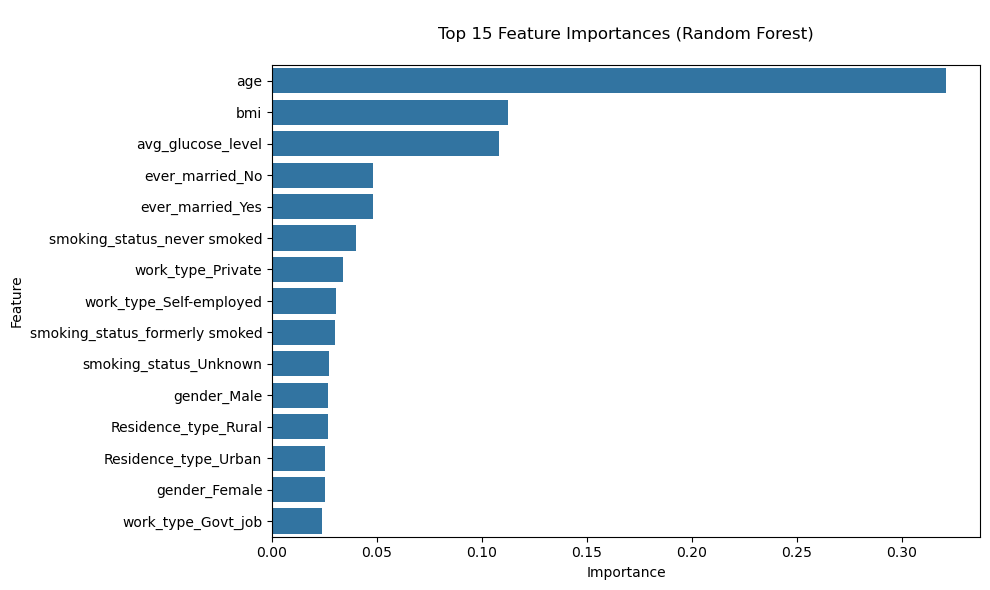

In [56]:
# Create a bar plot for the top 15 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feat_imp.head(15))

# Add title and axis labels for clarity
plt.title("\nTop 15 Feature Importances (Random Forest)\n")
plt.xlabel("Importance")
plt.ylabel("Feature")

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plot
plt.show()